### Helpful resources:
* [Guide to Markdown](https://paperhive.org/help/markdown)
* [Guide to LaTeX Math symbols](http://tug.ctan.org/info/undergradmath/undergradmath.pdf)
* [Python Cheat Sheets](https://ehmatthes.github.io/pcc/cheatsheets/README.html)
* [Moving to Python from MATLAB](https://bastibe.de/2013-01-20-a-python-primer-for-matlab-users.html)

# Lab #4: El Nino & Southern Oscillation
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
Only part of what make El Nino South Oscillation (ENSO) started was understood. When ENSO happened, normal sea events was disturbed. Before we explore about ENSO, we wil look about what normal sea events. Normal sea events are that trade winds flow from east to west. With this trade winds, the warm water will also flow from east to west, which created a strong east-west gradient of sea surface temperatures. The water level in west will also be lower than water level in east, which happened because difference in temperature.
In other hands, when ENSO happened, the sea surface temperature and atmoshperic pressure shows anomalies. The wind flows from east to west become weak, which then reduce the water flow from east to west. Thus, the higher water level from west zone went to the east, which then make east zone's water level become higher than normal.
As we can see, ENSO events will bring great domino effect to the surroundings.

The goal of this lab is to see the water level for the four stations, plotting the ONI and SOI to the graph, and see if we can figure out the periodicity of the ENSO signal. 

## Data
The datasets used are SPac_sea-level_1979-2016.csv and ENSO indices.csv.  
The SPac_sea-level_1979-2016.csv datasets from line 6 to line 10 is about the four stations name, latitude, and longitude.  
Then, the line 12 to the last line is about the date and the four station's water level anomalies.  
The ENSO_indices.csv datasets consists of the dates, Oceanic Nino Index (ONI), and Souther Oscillation Index (SOI) calculated at Tahiti and Darwin, Australia.

----

## Approach and Results
Here I import the critical library/module for this lab.

In [2]:
# Import critical libraries:
# !pip install cartopy
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from dateutil.relativedelta import relativedelta
import cartopy.crs as ccrs
# Turn on in-line plotting:
%matplotlib inline

### Question 1
Here we use the Cartopy commands to visually view the four station, which are Galapagos, Samoa, Christmas, and Guam.

In [3]:
# read the latitude and longitude for the four stations
data = np.genfromtxt('./SPac_sea-level_1979-2016.csv', delimiter=',', 
                     skip_header=6, usecols= (0,1,2), max_rows = 4, 
                     dtype=None, encoding = 'utf-8')

Text(-157.48, 1.98, 'Christmas (Christmas)')

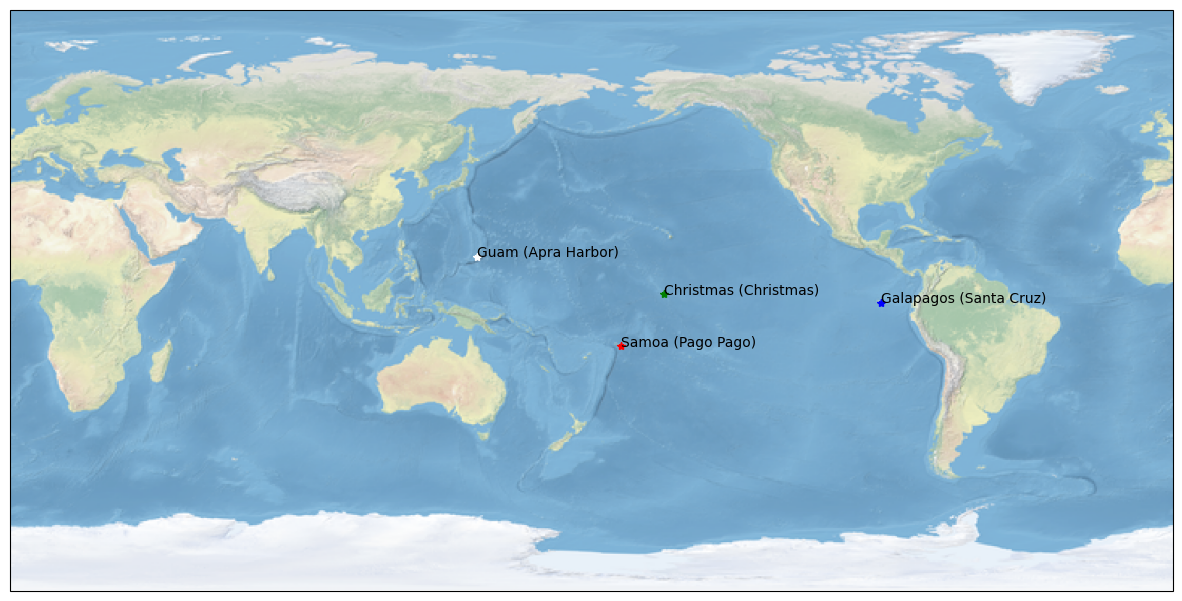

In [4]:
fig = plt.figure(figsize = (15,15))
# make a plot, using the cartopy in the projection
ax = fig.add_subplot(111, projection = ccrs.PlateCarree(central_longitude=180))
ax.stock_img()
# First location, Samoa (Pago Pago)
ax.plot(data[0][2], data[0][1], 'r*', transform=ccrs.PlateCarree())
ax.text(data[0][2], data[0][1], f'{data[0][0]}', transform=ccrs.PlateCarree())

# Second location, Galapagos (Santa Cruz)
ax.plot(data[1][2], data[1][1], 'b*', transform=ccrs.PlateCarree())
ax.text(data[1][2], data[1][1], f'{data[1][0]}', transform=ccrs.PlateCarree())

# Third location, Guam (Apra Harbor)
ax.plot(data[2][2], data[2][1], 'w*', transform=ccrs.PlateCarree())
ax.text(data[2][2], data[2][1], f'{data[2][0]}', transform=ccrs.PlateCarree())

# Fourth location, Christmas (Christmas)
ax.plot(data[3][2], data[3][1], 'g*', transform=ccrs.PlateCarree())
ax.text(data[3][2], data[3][1], f'{data[3][0]}', transform=ccrs.PlateCarree())

After plotting the location in the map, we will now make a hypthesis on the water level for each station.
But first, we will try to determine where each station is in the pacific ocean.

Galapagos is located in eastern pacific ocean.  
Guam is located in western pacific ocean.  
samoa in the south pacific ocean.
Chrismas in the central northern.  
I am expecting for sea level, from highest to lowest, to be at Guam, then Samoa, Christmas, and Galapagos, under normal condition.

### Question 2
Now we will used the datasets mentioned in the data section above, which are SPac_sea_level_1979-2016.csv and ENSO_indices.csv.  
First we will read the SPac_sea_level_1979-2016.csv file.

In [5]:
tconvert = lambda x: dt.datetime.strptime(str(x), '%m/%d/%y %H:%M')
sea_level_data = np.genfromtxt('./SPac_sea-level_1979-2016.csv', converters= {0:tconvert},
                               delimiter=',', skip_header=11, 
                                usecols= (0, 1, 2, 3, 4), dtype=None, encoding = 'utf-8', names=True)
print(sea_level_data)

[(datetime.datetime(1979, 1, 16, 12, 0),    9,  -74,   68,  -92)
 (datetime.datetime(1979, 2, 15, 0, 0),  -26, -118,   45, -158)
 (datetime.datetime(1979, 3, 16, 12, 0),   -5,  -57,  -62, -111)
 (datetime.datetime(1979, 4, 16, 0, 0),  -53,  -56,  -45,  -85)
 (datetime.datetime(1979, 5, 16, 12, 0),  -77,  -48,  -40,  -87)
 (datetime.datetime(1979, 6, 16, 0, 0),  -52,  -12,  -14,  -72)
 (datetime.datetime(1979, 7, 16, 12, 0),  -43,  -27,  -34,  -18)
 (datetime.datetime(1979, 8, 16, 12, 0),  -36,  -27,  -87,  -52)
 (datetime.datetime(1979, 9, 16, 0, 0),   15,  -85,  -99,  -81)
 (datetime.datetime(1979, 10, 16, 12, 0),    9,  -51,   17,  -81)
 (datetime.datetime(1979, 11, 16, 0, 0),  -24,  -47,   57,  -27)
 (datetime.datetime(1979, 12, 16, 12, 0),   -6,  -96,   40,  -74)
 (datetime.datetime(1980, 1, 16, 12, 0),   -4,  -68,   43,  -89)
 (datetime.datetime(1980, 2, 15, 12, 0),  -25, -141,   29,  -80)
 (datetime.datetime(1980, 3, 16, 12, 0),  -69,  -61,   30,  -63)
 (datetime.datetime(1980, 4

Then, we will plot the sea-level height anomalies for each of the four stations in the file.

In [6]:
# start = dt.datetime(1979,1,16)
# time = [start + relativedelta(months=i) for i in range(0,(2016 - 1979 + 1)*12)]
# print(time)
# print(time[36])
# print(time[48])
# print(time[216])
# print(time[228])
# print(time[432])
# print(time[444])
# axes_list[i].axvline(time[60])
# axes_list[i].axvline(time[216])
# axes_list[i].axvline(time[240])
# axes_list[i].axvline(time[432])
# axes_list[i].axvline(time[455])

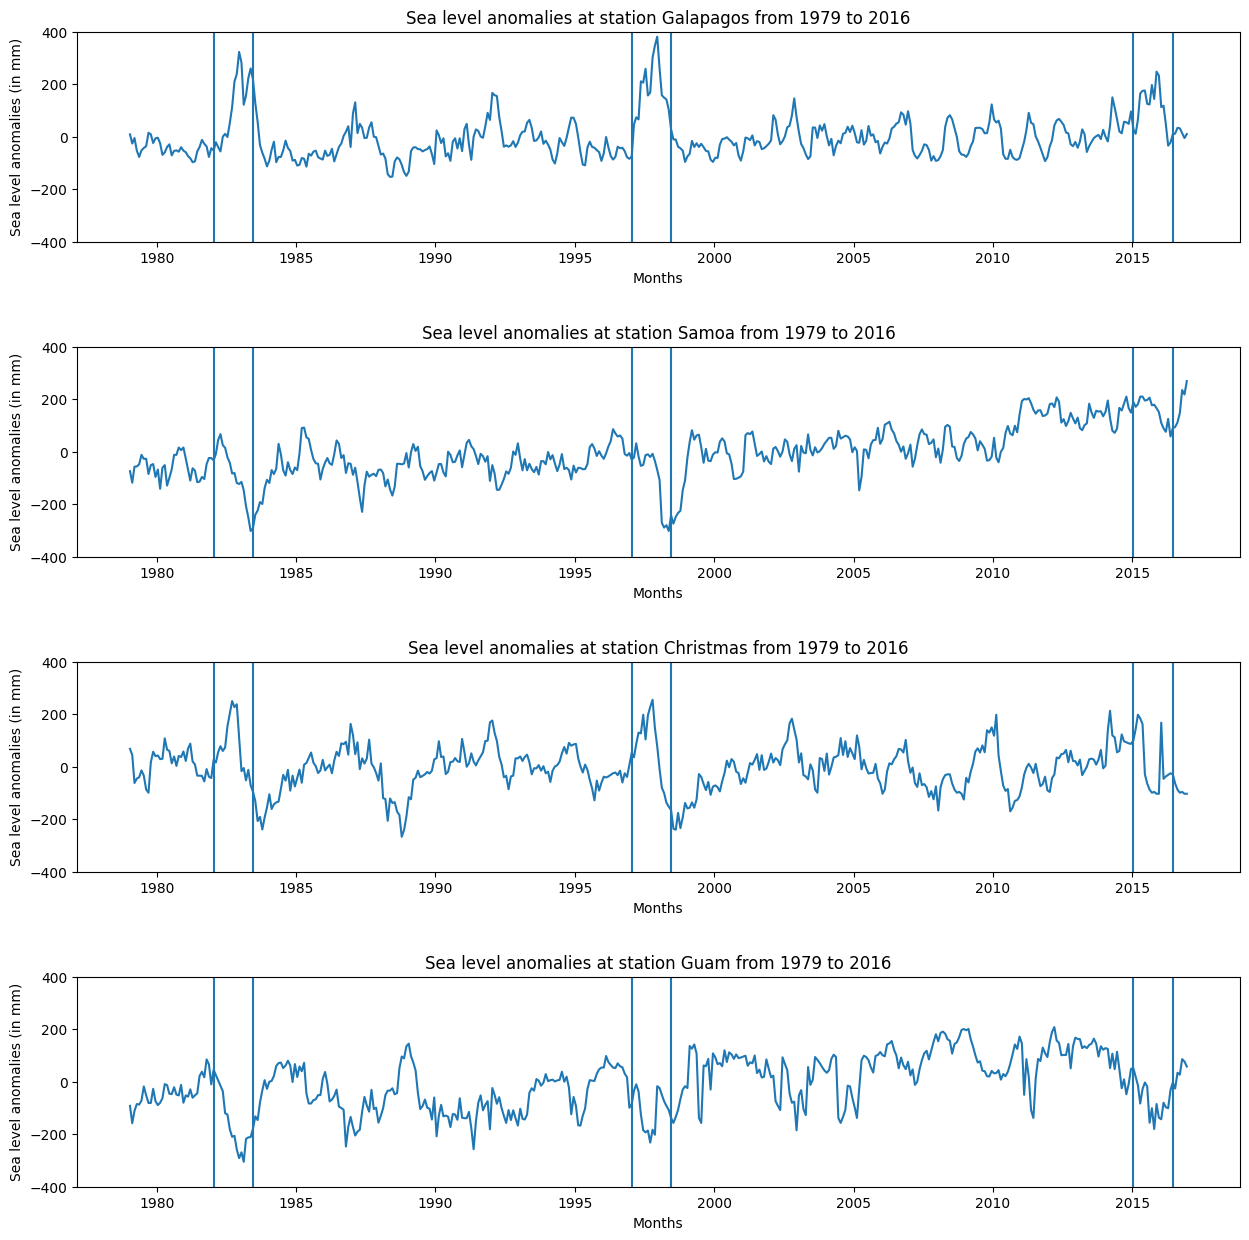

In [7]:
# Make a figure variable 
fig = plt.figure(figsize = (15,15))

# make a subplot of 4 rows and 1 column
# use shared = "row" to standardize the y-axes for the sea level height-anomalies
ax1, ax2, ax3, ax4 = fig.subplots(4 , 1, sharey='row')
axes_list = [ax1, ax2, ax3, ax4]
station_list = ['Galapagos', 'Samoa', 'Christmas', 'Guam']
for i in range(4):
    # Plot the axes with the sea level anomalies to speficic station against the month
    axes_list[i].plot(sea_level_data['Date'], sea_level_data[station_list[i]])
    
    # give title and label
    axes_list[i].set_title(f"Sea level anomalies at station {station_list[i]} from 1979 to 2016")
    axes_list[i].set_xlabel(f"Months")
    axes_list[i].set_ylabel(f"Sea level anomalies (in mm)")
    
    # set y-axes boundary to be from -400 to 400
    axes_list[i].set_ylim([-400,400])
    
    # axes_list[i].axhline(np.max(sea_level_data[station_list[i]]))
    # set the line from 1982 to 1983, 1997 to 1998, and 2015 to 2016 for more clearer visualization
    axes_list[i].axvline(dt.datetime(1982, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1983, 6, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1997, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1998, 6, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(2015, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(2016, 6, 16, 0, 0)) 

    # Put space in between subplots for readibility
    plt.subplots_adjust(hspace = 0.5)

From the figure, we will put our focus in the years from 1982 to 1983, from 1997 to 1998, and from 2015 to 2016, which is when the three largest El Nino events.  
These years have are between three pair of vertical lines plotted above.  

For Galapagos, in the year 1982 to 1983, from 1997 to 1998, and from 2015 to 2016, its water level was mostly above the 0.  
For Samoa, in the year 1982 to 1983, from 1997 to 1998, and from 2015 to 2016, its water level was mostly below the 0.  
For Christmas, in the year 1982 to 1983, from 1997 to 1998, and from 2015 to 2016, its water level was mostly above the 0.  
For Guam, in the year 1982 to 1983, from 1997 to 1998, and from 2015 to 2016, its water level was mostly below the 0.  

The noticable patterns here were the opposite of the hypothesis made in question 1.  
The hypothesis made are the station in the western will have higher water level than the station in the eastern, but instead, the figure above shows that the station in the eastern are the one that have higher water level, higher than the station in the western.
Sea level anomalies in Guam and Samoa seems to be lower than Christmas and Galapagos.  
This happens because even though Guam and Samoa were west to the Christmas and Galapagos, and their supposed water level should be lower than Christmas and Galapagos, El Nino happened.

### Question 3
Now, we want to include the SOI and ONI indices in out plot aboves.
To do that, we will need to read the ENSO_indices.csv files, which contained the SOI and ONI indices data.

In [8]:
# making a function to convert data entry from string into datetime datatype
tconvert = lambda x: dt.datetime.strptime(str(x), '%m/%d/%y %H:%M')
# reading the ENSO_indices.csv files, which contained Oceanic Nino Index (ONI) and Southern Oscillation Index (SOI)
ENSO_data = np.genfromtxt('./ENSO_indices.csv', converters= {0:tconvert},
                               delimiter=',', skip_header=5, 
                     dtype=None, encoding = 'utf-8', names=True)

Then we want to calculate the correlation between ONI indices and SOI indices

In [9]:
coeff = np.corrcoef(ENSO_data['ONI'], ENSO_data['SOI'])
print(coeff[0][1])

-0.747700954033272


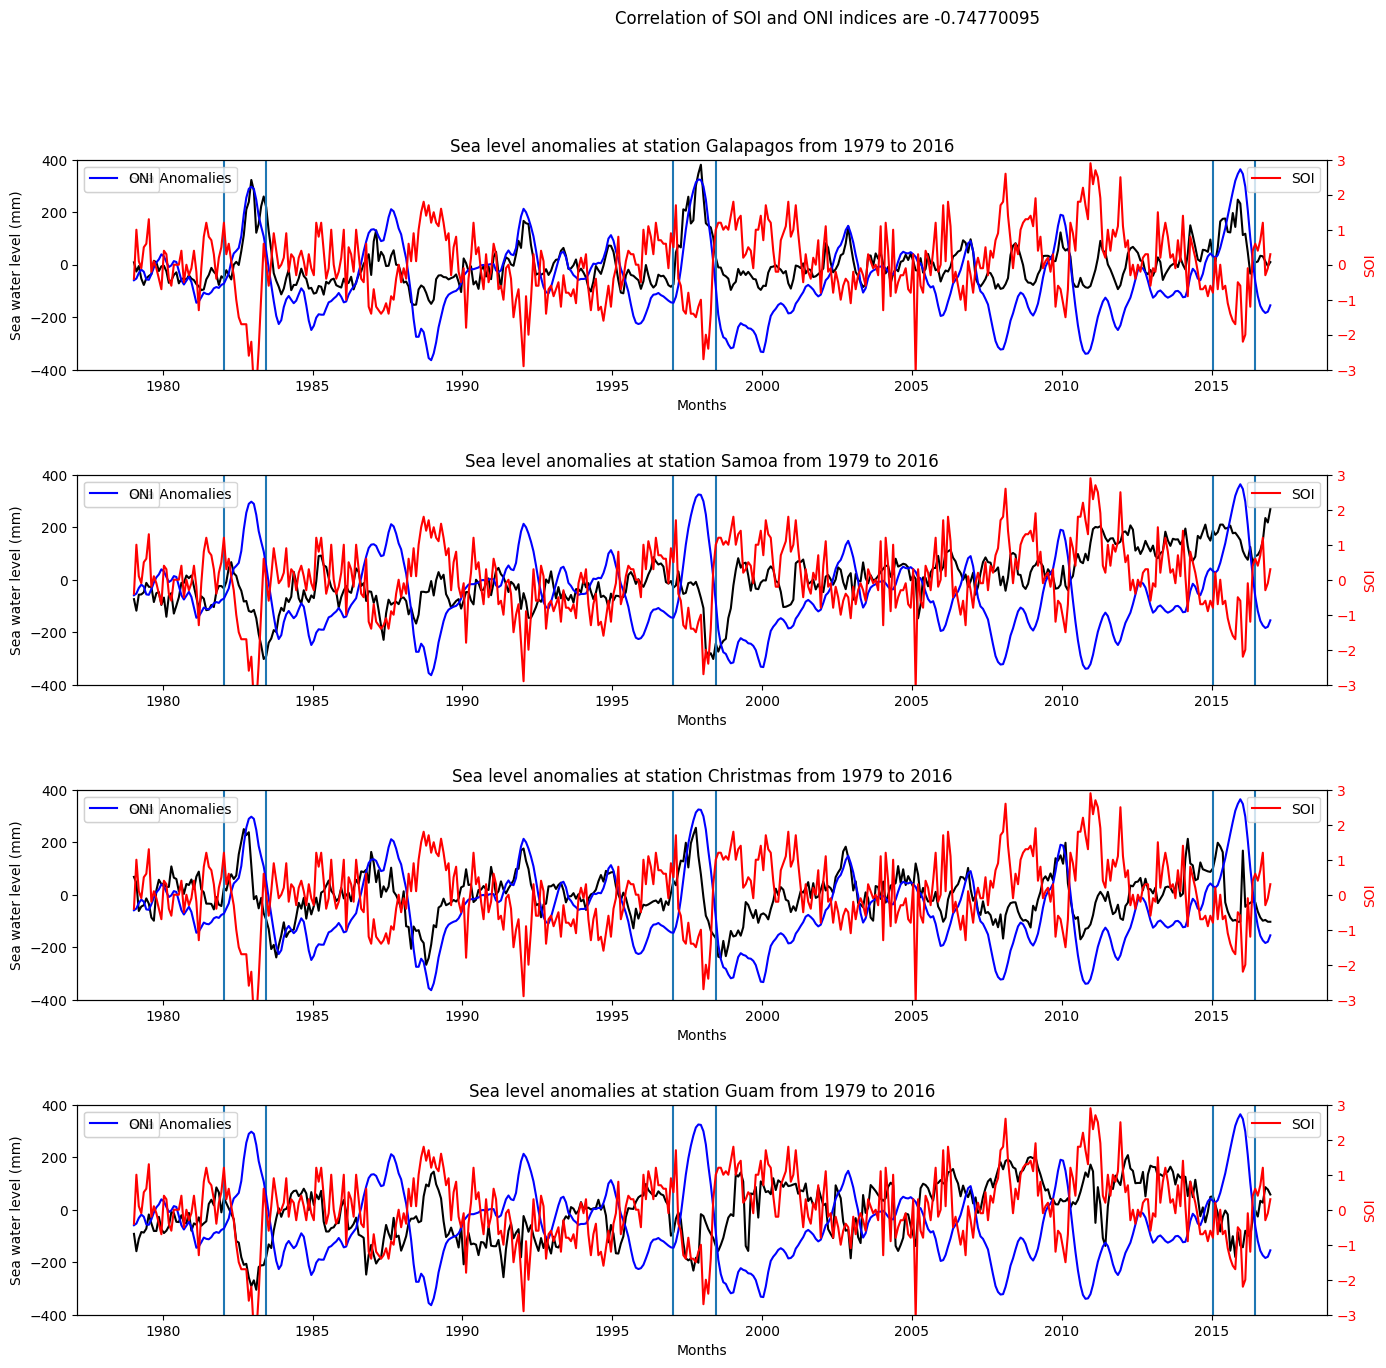

In [10]:
fig = plt.figure(figsize = (20, 15))
ax1, ax2, ax3, ax4 = fig.subplots(4 , 1, sharey='row')
axes_list = [ax1, ax2, ax3, ax4]
station_list = ['Galapagos', 'Samoa', 'Christmas', 'Guam']


# Include the correaltion of SOI and ONI indices in the figure's title.
fig.suptitle(f"Correlation of SOI and ONI indices are -0.74770095")

# plot each station
for i in range(4):
    plt.subplots_adjust(hspace = 0.5, right = 0.75)
    # Plot the original 
    p0, = axes_list[i].plot(sea_level_data['Date'], sea_level_data[station_list[i]], color = 'black', label = "Sea Anomalies")
    
    # Make twin axes for ONI and SOI
    par1 = axes_list[i].twinx()
    par2 = axes_list[i].twinx()
    p1, = par1.plot(sea_level_data['Date'], ENSO_data['ONI'], color = 'blue', label = "ONI")
    p2, = par2.plot(sea_level_data['Date'], ENSO_data['SOI'], color = 'red', label = "SOI")  

    # Give the original plot title and label  
    axes_list[i].set_title(f"Sea level anomalies at station {station_list[i]} from 1979 to 2016")
    axes_list[i].set_xlabel(f"Months")
    axes_list[i].set_ylabel(f"Sea water level (mm)")    
    # set limit for y axis of the original plot from -400 to 400
    axes_list[i].set_ylim([-400,400])
    # turn off axis for ONI for readibility
    par1.set_axis_off()
    # set limit for y axis in the right for SOI from -3 to 3
    par2.set_ylim([-3, 3])
    # put y axis label for SOI
    par2.set_ylabel('SOI', color='red')
    par2.tick_params(axis='y', labelcolor= 'red')
    
    # axes_list[i].axhline(0)
    # set the line from 1982 to 1983, 1998 to 1998, and 2015 to 2016 for more clearer visualization
    axes_list[i].axvline(dt.datetime(1982, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1983, 6, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1997, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(1998, 6, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(2015, 1, 16, 0, 0))
    axes_list[i].axvline(dt.datetime(2016, 6, 16, 0, 0)) 
    
    # call legend function to make the annotation appear
    axes_list[i].legend(loc='best')
    par1.legend(loc='best')
    par2.legend(loc='best')

The correlation (and the plot) shows that SOI and ONI are inversely related, as when ONI's value is high, SOI's value will be low, and vice versa.  
Now let's put our focus on Guam, where it is located in Western Pacific ocean. In normal sea events, its water level will be higher than the eastern Pacific Ocean.  
Now if we are looking at SOI, which are about the Southern Oscillation at two places in Austraia, it also went down with the water level in Guam.  
In other words, if we look at the water level and SOI and if both are lower than normal, highly likely it is ENSO event happening.  
Now, from the figure, the ENSO event heppened in between 1982-1983, 1987- 1988, 1992-1993, 1997-1998, 2002-2003, 2005, and 2015-2016.  
It looks like ENSO happened every five years between 1982 to 2003, and then irregular after that, in 2005 and 2015-2016.  

## Conclusions
ENSO events change the normal sea events, making anomalies sea temperatures and anomalies sea temperature happened.  
By using these anomalies, we can calculate ONI and SOI, which then we can used to plot it on a figure.  
Then using these figures, we can observe and compare the sea water level and SOI indexes, and see if there is a trend respective to the the location.
In addition, SOI and ONI are inversely related, which makes it have negative correlation.

## References
List any references used